# Predicting renewable share from weather

`03_visualization.ipynb` asked *is there a relationship* between weather and Ireland's renewable share. This notebook asks a sharper question: *can weather actually predict it*, evaluated properly - a held-out test set, a naive baseline to beat, and a model matched to how much data actually exists.

"Proper" here deliberately does **not** mean deep learning. With a dataset that's currently tens of rows and grows by about four a day (one point per scheduled run), a large model would memorize noise, not learn a relationship - the honest choice at this data volume is a small, interpretable model, evaluated rigorously enough that the *evaluation* is the part that's genuinely rigorous, not the model architecture.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

merged = pd.read_csv(
    Path("../data/processed/weather_generation_merged.csv"), index_col="timestamp", parse_dates=True
)
merged = merged.sort_index()
print(f"{len(merged)} hourly rows")
merged.head()

25 hourly rows


,renewable_pct,total_generation_mw,renewable_mw,temperature_2m,wind_speed_10m,shortwave_radiation
timestamp,,,,,,
2026-08-14 15:00:00+00:00,38.253333,1482.0,567.0,8.0,15.0,0.0
2026-08-14 16:00:00+00:00,39.295000,1594.0,626.5,8.5,18.0,0.0
2026-08-14 17:00:00+00:00,40.620000,1709.5,694.5,9.0,21.0,0.0
2026-08-14 18:00:00+00:00,42.357500,1800.0,762.5,9.5,24.0,40.0
2026-08-14 19:00:00+00:00,42.172500,1898.0,800.5,10.0,27.0,80.0


## Features

The three weather readings, plus hour-of-day encoded as sine/cosine (so midnight and 1am end up close together in feature space, not 23 hours apart the way a raw `0`/`23` encoding would put them). Included as a cheap additional signal to test, not because we're sure a diurnal pattern beyond what radiation already captures actually exists - the model and its evaluation will show whether it earns its place.

`total_generation_mw` and `renewable_mw` are deliberately **excluded** even though they're in the merged dataset - they're downstream of the same generation numbers `renewable_pct` is computed from, so including them would be leaking the answer into the input, not predicting from an independent signal the way weather is.

In [2]:
features = merged[["wind_speed_10m", "shortwave_radiation", "temperature_2m"]].copy()

# pd.read_csv's return type doesn't statically know its index became a
# DatetimeIndex via parse_dates=True - an explicit cast (rather than a
# lint-suppressing comment) gives .hour/.minute back to the type checker
# without hiding any other real error on this line.
timestamps = pd.DatetimeIndex(merged.index)
hour = timestamps.hour + timestamps.minute / 60
features["hour_sin"] = np.sin(2 * np.pi * hour / 24)
features["hour_cos"] = np.cos(2 * np.pi * hour / 24)

target = merged["renewable_pct"]

features.head()

,wind_speed_10m,shortwave_radiation,temperature_2m,hour_sin,hour_cos
timestamp,,,,,
2026-08-14 15:00:00+00:00,15.0,0.0,8.0,-0.707107,-7.071068e-01
2026-08-14 16:00:00+00:00,18.0,0.0,8.5,-0.866025,-5.000000e-01
2026-08-14 17:00:00+00:00,21.0,0.0,9.0,-0.965926,-2.588190e-01
2026-08-14 18:00:00+00:00,24.0,40.0,9.5,-1.000000,-1.836970e-16
2026-08-14 19:00:00+00:00,27.0,80.0,10.0,-0.965926,2.588190e-01


## A time-aware train/test split

`sklearn.model_selection.train_test_split`'s default random shuffle would be wrong here: it can put an hour into training and the *immediately adjacent* hour into test, and adjacent hours are highly correlated (weather and grid generation both change slowly) - the model would effectively get to peek at near-identical near-future data, and the reported score would be optimistic in a way that wouldn't hold up on genuinely new data. The correct split for a time series is chronological: train on the earlier portion, test on the most recent portion, exactly like how this model would actually be used - trained on history, evaluated on what comes next.

In [3]:
split_index = int(len(features) * 0.8)

X_train, X_test = features.iloc[:split_index], features.iloc[split_index:]
y_train, y_test = target.iloc[:split_index], target.iloc[split_index:]

print(f"train: {len(X_train)} rows ({X_train.index.min()} to {X_train.index.max()})")
print(f"test:  {len(X_test)} rows ({X_test.index.min()} to {X_test.index.max()})")

train: 20 rows (2026-08-14 15:00:00+00:00 to 2026-08-15 10:00:00+00:00)
test:  5 rows (2026-08-15 11:00:00+00:00 to 2026-08-15 15:00:00+00:00)


## Baseline: persistence

The standard baseline for a time series is "predict whatever it was last period" - if a model can't beat that, weather isn't adding predictive value over just watching the grid itself. Any model judged only against its own R², with no baseline in sight, is an easy number to over-interpret.

In [4]:
baseline_predictions = target.shift(1).iloc[split_index:]
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"persistence baseline - MAE: {baseline_mae:.2f} pts, R\u00b2: {baseline_r2:.2f}")

persistence baseline - MAE: 2.60 pts, R²: -17.95


A negative R² here isn't a bug - it means the baseline does *worse* than just predicting the mean every time, which is entirely possible (and common) when the test set is this small. R² is a comparison against "predict the mean of the test set," and with only 5 points, that comparison point itself is barely stable; the number to actually watch at this data volume is MAE, which stays interpretable (a plain "how many percentage points off, on average") no matter how few rows there are.

## The model: linear regression

Chosen deliberately, not by default: at this data volume a linear model won't overfit, its coefficients are directly interpretable (which weather variable matters, and in which direction), and it gives a real, honest baseline to compare a tree-based model against later, once there's enough history (weeks, not hours) for one to actually learn something instead of memorizing it.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

model_mae = mean_absolute_error(y_test, predictions)
model_r2 = r2_score(y_test, predictions)

print(f"linear regression   - MAE: {model_mae:.2f} pts, R\u00b2: {model_r2:.2f}")
print(f"persistence baseline - MAE: {baseline_mae:.2f} pts, R\u00b2: {baseline_r2:.2f}")
print()
if model_mae < baseline_mae:
    print(f"model beats the baseline by {baseline_mae - model_mae:.2f} points of MAE")
else:
    print("model does not beat the persistence baseline on this test window")

linear regression   - MAE: 2.34 pts, R²: -8.91
persistence baseline - MAE: 2.60 pts, R²: -17.95

model beats the baseline by 0.26 points of MAE


## Which features matter

Linear regression coefficients: how many percentage points `renewable_pct` moves per one-unit increase in each feature, all else held equal.

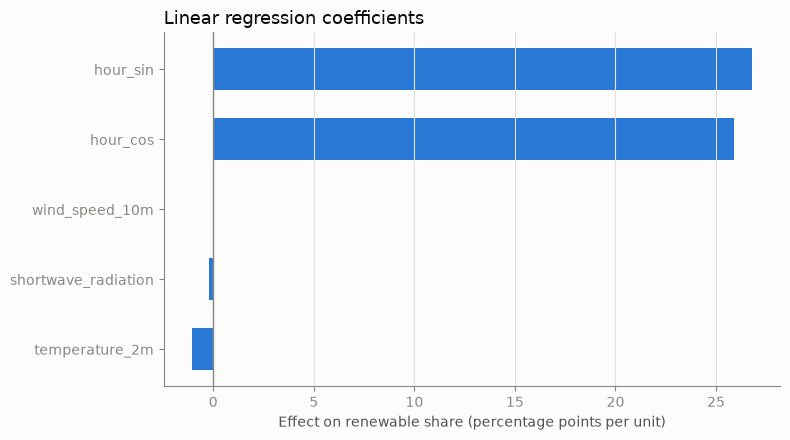

In [6]:
COLOR_BG = "#fcfcfb"
COLOR_INK = "#0b0b0b"
COLOR_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BLUE = "#2a78d6"

plt.rcParams.update(
    {
        "figure.facecolor": COLOR_BG,
        "axes.facecolor": COLOR_BG,
        "axes.edgecolor": COLOR_MUTED,
        "axes.labelcolor": COLOR_SECONDARY,
        "text.color": COLOR_INK,
        "xtick.color": COLOR_MUTED,
        "ytick.color": COLOR_MUTED,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "font.family": "sans-serif",
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

coefficients = pd.Series(model.coef_, index=features.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
# .to_numpy() instead of .values: Series.values is typed as a broad
# ndarray | ExtensionArray | Categorical union, which matplotlib's stricter
# stubs don't accept for a numeric argument - .to_numpy() is the modern,
# precisely-typed pandas API for exactly this case.
ax.barh(coefficients.index, coefficients.to_numpy(), color=COLOR_BLUE, height=0.6)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)
ax.set_xlabel("Effect on renewable share (percentage points per unit)")
ax.set_title("Linear regression coefficients", loc="left", fontsize=13)
ax.grid(True, axis="x", linewidth=0.8)
ax.grid(False, axis="y")
fig.tight_layout()
plt.show()

## Predicted vs. actual

Every point on the diagonal reference line is a perfect prediction - a scatter of predicted against actual, not a time series, so how far off each individual prediction was is visible directly as vertical distance from that line.

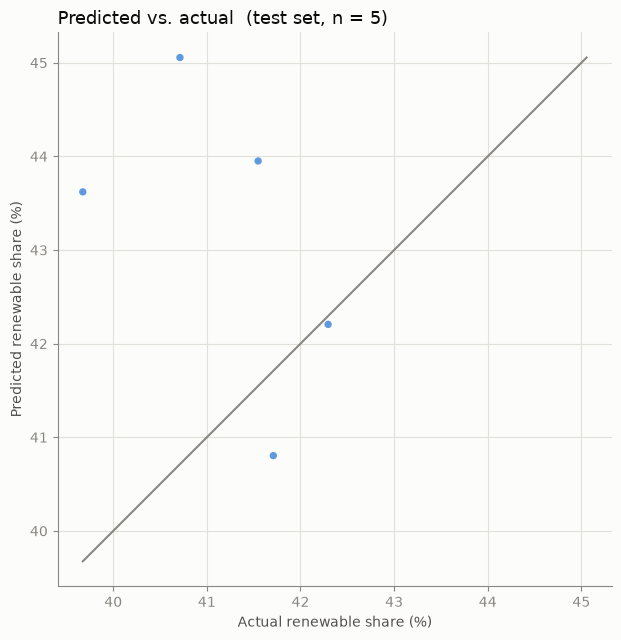

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, predictions, s=28, color=COLOR_BLUE, alpha=0.75, edgecolors="none")

lo = min(y_test.min(), predictions.min())
hi = max(y_test.max(), predictions.max())
ax.plot([lo, hi], [lo, hi], color=COLOR_MUTED, linewidth=1.5)

ax.set_xlabel("Actual renewable share (%)")
ax.set_ylabel("Predicted renewable share (%)")
ax.set_title(f"Predicted vs. actual  (test set, n = {len(y_test)})", loc="left", fontsize=13)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

## Honest caveats

- **The test set is tiny right now** - a handful of hours, since the scheduled workflow only recently went live. Neither the MAE/R² numbers above nor "model beats baseline" should be read as a settled result yet; they're a methodology proven correct (time-aware split, real baseline, no target leakage), waiting on more data to become a genuinely reliable one.
- **Re-running this notebook later requires nothing new** - re-run `02_transformations.ipynb` first to refresh the merged CSV against however much history has accumulated since, then re-run this notebook. The split, baseline, and evaluation all just work on however many rows exist.
- **Worth revisiting once there's real history (weeks, not hours)**: a tree-based model (e.g. a small `RandomForestRegressor`) could capture non-linear effects a linear model can't - but attempting that now, on this little data, would just overfit and produce a misleadingly good-looking training score. Reaching for a bigger model before the data justifies it is the mistake this notebook is deliberately avoiding.